In [25]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
print(diabetes.keys()) 
print(type(diabetes))

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])
<class 'sklearn.utils._bunch.Bunch'>


In [26]:
import pandas as pd
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


# ML 모델링 프로세스

1. 데이터 수집
2. 전처리 (클렌징)
3. 탐색 EDA
4. 모델 선택
5. 모델 학습
6. 모델 평가
7. 모델 개선 ~> 3/4/5번
8. 모델 배포 ~> AI 서버, APP 개발

# 데이터 수집

In [4]:
from sklearn.datasets import load_iris
iris = load_iris()
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [5]:
iris_data = iris.data
iris_data.shape # X

(150, 4)

In [6]:
iris_label = iris.target # y = 0,1,2
iris_label 

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

X >> iris_data
y(target) >> iris_label > category 분류모델

# 데이터 탐색 > 데이터 분할

훈련용:테스트용 = 8:2 or 7:3

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris_data, 
                                                    iris_label,
                                                    test_size = 0.2,
                                                    random_state=42)
X_train.shape, X_test.shape # X의 훈련용, 테스트용 분할결과

((120, 4), (30, 4))

In [8]:
X_train[:5]

array([[4.6, 3.6, 1. , 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [6.7, 3.1, 4.4, 1.4],
       [4.8, 3.4, 1.6, 0.2],
       [4.4, 3.2, 1.3, 0.2]])

In [9]:
y_train.shape, y_test.shape # y의 훈련용, 테스트용 분할결과

((120,), (30,))

# 모델 선택 > DecisionTreeClassifier

In [10]:
from sklearn.tree import DecisionTreeClassifier # 클래스 알고리즘 구현
iris_Dt_clf=DecisionTreeClassifier() # 객체생성
iris_Dt_clf # Not fitted 

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

# 모델 학습
x,y를 넣어서 학습 '훈련' > train  

In [11]:
iris_Dt_clf.fit(X_train, y_train)
iris_Dt_clf # fitted

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

# 모델 평가 
X_test 값을 넣어서 어떤 y 값을 주는지 확인

In [12]:
iris_pred = iris_Dt_clf.predict(X_test)
iris_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [13]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, iris_pred)

1.0

In [14]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, iris_pred)

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

## 시각화를 통한 모델 성능 평가
cf. 해당 예제는 정확도가 1이라 'Actual = Predicted'

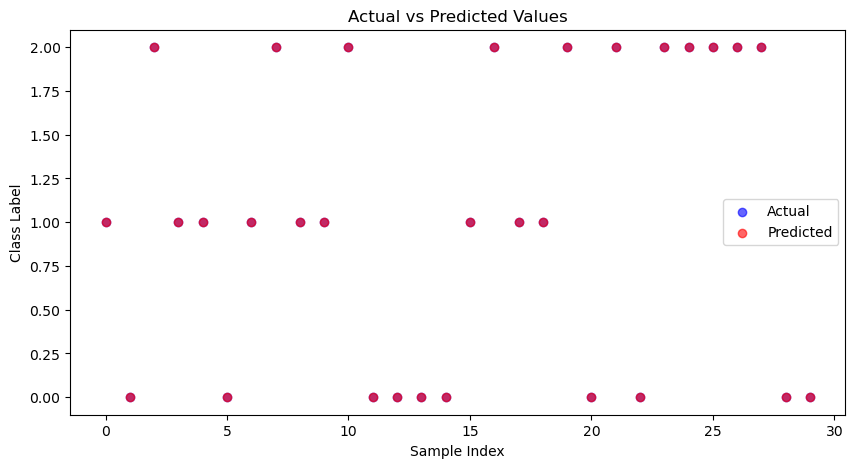

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# 샘플 인덱스 생성
x = np.arange(len(y_test))

plt.figure(figsize=(10, 5))

# 실제값 (파란색)
plt.scatter(x, y_test, color='blue', label='Actual', alpha=0.6)

# 예측값 (빨간색)
plt.scatter(x, iris_pred, color='red', label='Predicted', alpha=0.6)

plt.xlabel('Sample Index')
plt.ylabel('Class Label')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.show()

# 추가예제

In [29]:
from sklearn.datasets import load_wine
wine = load_wine()
wine.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])

In [32]:
wine_data = wine.data
wine_label = wine.target
wine_data, wine_label

(array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]], shape=(178, 13)),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(wine_data, 
                                                    wine_label,
                                                    test_size = 0.2,
                                                    random_state=42)
X_train.shape, X_test.shape 

((142, 13), (36, 13))

In [301]:
y_train.shape, y_test.shape 

((142,), (36,))

In [ ]:
wine_Dt_clf=DecisionTreeClassifier(random_state=42)
wine_Dt_clf 

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",41
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [303]:
wine_Dt_clf.fit(X_train, y_train)
wine_Dt_clf

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",41
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [304]:
wine_pred = wine_Dt_clf.predict(X_test)
wine_pred

array([2, 0, 0, 0, 1, 2, 2, 1, 2, 0, 0, 1, 0, 2, 1, 0, 0, 1, 2, 1, 0, 1,
       2, 0, 2, 1, 1, 0, 2, 0, 0, 1, 2, 1, 1, 1])

In [305]:
accuracy_score(y_test, wine_pred)

1.0

array([[10,  0,  0],
       [ 0,  9,  0],
       [ 0,  0, 11]])

# 의사결정나무 알고리즘

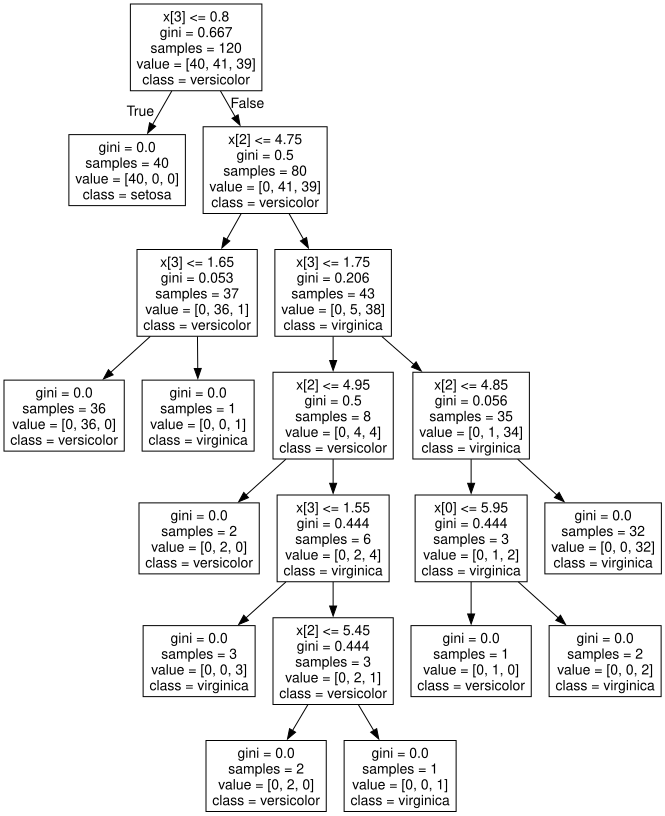

In [16]:
import graphviz
from sklearn.tree import export_graphviz

export_graphviz(iris_Dt_clf, out_file = 'iris_tree.dot', class_names=iris.target_names) # 모델의 트리를 파일로 저장

with open('iris_tree.dot') as f:
  dot_graph=f.read() # tree 파일 읽기

graphviz.Source(dot_graph)

# k-fold cross validation 교차검증

In [17]:
import pandas as pd
iris_data_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_data_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [18]:
iris_data_df['label'] = iris.target
iris_data_df['label'].value_counts()

label
0    50
1    50
2    50
Name: count, dtype: int64

In [19]:
from sklearn.model_selection import KFold
kfold_5 = KFold(n_splits=5)
kfold_5

KFold(n_splits=5, random_state=None, shuffle=False)

In [20]:
iris_cv_clf = DecisionTreeClassifier(random_state=42)
iris_cv_clf

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [ ]:
for train_index, test_index in kfold_5.split(iris_data):
  X_train, X_test = iris_data[train_index],  iris_data[test_index]
  y_train, y_test = iris_label[train_index],  iris_label[test_index]

  iris_cv_clf.fit(X_train, y_train) # 훈련
  pred = iris_cv_clf.predict(X_test) # 테스트
  acc = accuracy_score(y_test, pred) # 평가
  print(f'Accuracy: {acc:.4f}')

Accuracy: 1.0000
Accuracy: 1.0000
Accuracy: 0.8333
Accuracy: 0.9333
Accuracy: 0.8000


# 여기서부터 오후 
# cross_val_score()

In [46]:
from sklearn.model_selection import cross_val_score
X = iris.data
y = iris.target
iris_Dt_clf_cv = DecisionTreeClassifier(random_state=156)
cross_val_score(iris_Dt_clf_cv, X, y, cv=5, scoring='accuracy')

array([0.96666667, 0.96666667, 0.9       , 0.96666667, 1.        ])

# GridSearchCV

In [47]:
from sklearn.model_selection import GridSearchCV
iris_Dt_gcv = DecisionTreeClassifier(random_state=121)
params = {'max_depth':[1,2,3], 'min_samples_split':[2,3]}
grid_dt_cv = GridSearchCV(iris_Dt_gcv, cv=5, param_grid=params)
grid_dt_cv.fit(X,y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...dom_state=121)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [1, 2, ...], 'min_samples_split': [2, 3]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : 

In [48]:
pd.DataFrame(grid_dt_cv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001055,0.002109,0.000246,0.000492,1,2,"{'max_depth': 1, 'min_samples_split': 2}",0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.000000,5
1,0.000705,0.000804,0.000204,0.000409,1,3,"{'max_depth': 1, 'min_samples_split': 3}",0.666667,0.666667,0.666667,0.666667,0.666667,0.666667,0.000000,5
2,0.000635,0.000519,0.000432,0.000530,2,2,"{'max_depth': 2, 'min_samples_split': 2}",0.933333,0.966667,0.900000,0.866667,1.000000,0.933333,0.047140,3
3,0.000415,0.000830,0.000133,0.000266,2,3,"{'max_depth': 2, 'min_samples_split': 3}",0.933333,0.966667,0.900000,0.866667,1.000000,0.933333,0.047140,3
4,0.000000,0.000000,0.001194,0.001889,3,2,"{'max_depth': 3, 'min_samples_split': 2}",0.966667,0.966667,0.933333,1.000000,1.000000,0.973333,0.024944,1
5,0.000159,0.000319,0.000000,0.000000,3,3,"{'max_depth': 3, 'min_samples_split': 3}",0.966667,0.966667,0.933333,1.000000,1.000000,0.973333,0.024944,1


# 프로세스 연습: load_wine

In [49]:
from sklearn.datasets import load_wine

# ==========================================
# 1. 데이터 준비
# ==========================================
wine = load_wine()

# X: 문제 (알코올 농도, 색상 등 13가지 화학적 특성)
# y: 정답 (0, 1, 2로 나누어진 3가지 와인 품종)
X = wine.data
y = wine.target

# 전체 데이터를 학습용(80%)과 테스트용(20%)으로 분리
# random_state를 지정하면 실행할 때마다 똑같이 섞이게 됩니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=38)

# ==========================================
# 2. 모델 생성 및 학습
# ==========================================
# 의사결정나무 알고리즘 구현 클래스 생성 (깡통)
model = DecisionTreeClassifier(random_state=38)

# 학습용 문제와 정답을 주고 모델 학습시키기
model.fit(X_train, y_train)

# ==========================================
# 3. 예측 및 평가
# ==========================================
# 학습에 사용하지 않은 테스트용 문제(X_test)를 주고 예측해보기
y_pred = model.predict(X_test)

# 실제 정답(y_test)과 모델이 예측한 값(y_pred)을 비교하여 정확도 계산
accuracy = accuracy_score(y_test, y_pred)

print("=== 와인 품종 분류 결과 ===")
print(f"모델 정확도 : {accuracy * 100:.2f}%")

=== 와인 품종 분류 결과 ===
모델 정확도 : 94.44%


# wine data로 데이터스케일링
스케일링 = 표준화 for 변수들의 단위/크기 차이 조절
-> 거리기반 모델에서 특히 중요
<> 트리기반(의사결정나무, 랜덤포레스트, XGBoost)모델은 크기 자체가 아니라 분할 기준을 보기 때문에 스케일링이 거의 필요없음

cf. 트리: 순서 기반 "이 값이 특정 기준보다 큰가 작은가" 

In [50]:
wine = load_wine()
wine_df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
wine_df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [51]:
wine_df['target'] = wine.target
wine_df['target'].value_counts().sort_index()

target
0    59
1    71
2    48
Name: count, dtype: int64

## LogisticRegression

In [52]:
X=wine.data
y=wine.target

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=11)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((142, 13), (36, 13), (142,), (36,))

In [53]:
from sklearn.linear_model import LogisticRegression
wine_lr_clf = LogisticRegression(max_iter=36)
wine_lr_clf.fit(X_train,y_train)
wine_lr_pred=wine_lr_clf.predict(X_test)
accuracy_score(y_test, wine_lr_pred)

c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 36 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=36).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9722222222222222

## 스케일링 후 

In [54]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [55]:
from sklearn.linear_model import LogisticRegression
wine_lr_clf_scaled = LogisticRegression(max_iter=36)
wine_lr_clf_scaled.fit(X_train_scaled,y_train)
wine_lr_pred_scaled=wine_lr_clf_scaled.predict(X_test_scaled)
accuracy_score(y_test, wine_lr_pred_scaled)

1.0

In [56]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [59]:
models = {
  'KNN': KNeighborsClassifier(),
  'RF': RandomForestClassifier(),
  'LR':LogisticRegression()
}

for name, model in models.items():
  model.fit(X_train_scaled, y_train)
  y_pred = model.predict(X_test_scaled)
  print (f'{name} 모델의 정확도 : {accuracy_score(y_test, y_pred):.5f}')

KNN 모델의 정확도 : 1.00000
RF 모델의 정확도 : 0.97222
LR 모델의 정확도 : 1.00000


# 하이퍼파라미터 탐색
- 파라미터: 모델이 데이터로부터 학습해서 스스로 정함
- **하이퍼**파라미터 : 모델 학습 전에 사람이 정해줘야하는 설정값 

> 즉, 모델이 가장 잘 작동하도록 만드는 '설정값 조합'을 찾으라는 의미 = 여러 설정값 조합을 시험해보고, 검증 데이터 기준 성능이 가장 좋은 조합 선택

그리드 정의 : 실험해볼 후보값들의 범위를 미리 정해둠 > 격자(grid)위 모든 점을 시험

In [60]:
from sklearn.model_selection import GridSearchCV

In [61]:
# 모델 및 탐색할 하이퍼파라미터 그리드 정의
model_params = {
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9],            # 이웃의 수
            'weights': ['uniform', 'distance']      # 가중치 부여 방식
        }
    },
    'RF': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [50, 100, 200],         # 트리의 개수
            'max_depth': [None, 5, 10, 15],         # 트리의 최대 깊이
            'min_samples_split': [2, 5, 10]         # 노드를 분할하기 위한 최소 샘플 수
        }
    },
    'LR': {
        'model': LogisticRegression(random_state=42, max_iter=2000), 
        'params': {
            'C': [0.01, 0.1, 1, 10, 100],           # 규제 강도 (작을수록 강한 규제)
            'solver': ['lbfgs', 'liblinear']        # 최적화 알고리즘
        }
    }
}

In [ ]:
# GridSearchCV를 사용한 최적 파라미터 탐색 및 평가
for name, config in model_params.items():
    grid = GridSearchCV(config['model'], config['params'], cv=5, scoring='accuracy', n_jobs=-1) # cv=5는 5-Fold 교차 검증 의미
    grid.fit(X_train_scaled, y_train)
    
    # 최적 파라미터가 적용된 최고 성능의 모델 추출
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_scaled)
    
    print(f"[{name} 모델]")
    print(f" - 찾은 최적 파라미터: {grid.best_params_}")
    print(f" - 교차 검증 최고 정확도: {grid.best_score_:.5f}")
    print(f" - 테스트 데이터 최종 정확도: {accuracy_score(y_test, y_pred):.5f}")
    print("-" * 50)

[KNN 모델]
 - 찾은 최적 파라미터: {'n_neighbors': 7, 'weights': 'uniform'}
 - 교차 검증 최고 정확도: 0.95813
 - 테스트 데이터 최종 정확도: 1.00000
--------------------------------------------------
[RF 모델]
 - 찾은 최적 파라미터: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
 - 교차 검증 최고 정확도: 0.98621
 - 테스트 데이터 최종 정확도: 0.97222
--------------------------------------------------
[LR 모델]
 - 찾은 최적 파라미터: {'C': 0.1, 'solver': 'lbfgs'}
 - 교차 검증 최고 정확도: 0.97906
 - 테스트 데이터 최종 정확도: 1.00000
--------------------------------------------------


c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\miniconda3\envs\ml_edu\Lib\site-packages\sklearn\linear_m

💡 각 모델별 주요 하이퍼파라미터 설명
- KNN (KNeighborsClassifier)
  - n_neighbors: 몇 개의 가까운 이웃을 참고하여 예측할 것인가 결정
  - weights: 거리에 따라 가중치를 다르게 줄지(distance), 모두 똑같이 취급할 것인지(uniform)를 정함

- RF (RandomForestClassifier)
  - n_estimators: 숲을 구성할 나무(Decision Tree) 개수. 많을수록 성능이 좋아지지만 학습 시간이 늘어남
  - max_depth: 과적합(Overfitting)을 방지하기위해 각 나무가 자랄 수 있는 최대 깊이 제한

- LR (LogisticRegression)
  - C: 모델의 가중치를 제한하는 규제(Regularization)의 강도 (값이 작을수록 규제가 강해짐)
  - solver: 비용 함수를 최소화하는 최적화 알고리즘의 종류